In [1]:
# Cell 1: imports + load Model C parameter tables
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA_PROCESSED = Path("../data/processed")
DATA_RAW = Path("../data/raw")

# Accel: per-condition FOPDT params (curve_fit) from step-ups (Phase 2.1)
accel_params = pd.read_csv(DATA_PROCESSED / "phase21_fopdt_curvefit_per_condition.csv")

# Decel: per-condition FOPDT params (curve_fit) from step-downs (Phase 2.1)
decel_params = pd.read_csv(DATA_PROCESSED / "phase21_stepdown_curvefit_per_condition.csv")

# Static block constants (Phase 1.1/1.2) — locked
K_FWD = 26.94          # rpm/V, fit through origin, above-deadzone
K_REV = 24.52          # rpm/V
BREAKAWAY_FWD = 154
BREAKAWAY_REV = 144
DROPOUT_FWD = 114
DROPOUT_REV = 112
V_SUPPLY = 12.0        # PSU set-point

print("=== ACCEL params (per-condition) ===")
print(accel_params.to_string())
print("\n=== DECEL params (per-condition) ===")
print(decel_params.to_string())
print("\n=== ACCEL columns ===", list(accel_params.columns))
print("=== DECEL columns ===", list(decel_params.columns))


=== ACCEL params (per-condition) ===
  direction  pwm   K_ss_mean       Td_mean        Td_std    tau_mean    tau_std  rms_rise_mean  rms_ss_mean
0       fwd  160   52.076710  5.599882e-12  9.665896e-12  200.093685  22.019478       2.614922     2.122001
1       fwd  200  123.525330  4.918430e+00  8.588682e-01   95.097833   4.644765       2.477502     2.682848
2       fwd  240  209.740336  1.705761e+01  7.260611e-01  152.257963   2.738419       4.688881     4.196545
3       rev  160  -69.553323  6.892271e-12  1.193728e-11  191.651379  12.148197       4.029168     2.473888
4       rev  200 -131.348541  5.631620e+00  2.771833e-01   81.238787   0.937802       2.658032     3.298951
5       rev  240 -222.557999  2.348522e+01  6.392748e-01  144.427531   2.453339       7.172695     5.997176

=== DECEL params (per-condition) ===
  direction  start_pwm  target_pwm  y_init_mean  y_final_mean    Td_mean    Td_std    tau_mean   tau_std  rms_decel_mean
0       fwd        240           0   214.268616 

In [2]:
# Cell 2: Model C simulator — single-transition step inputs

def get_accel_params(direction, target_pwm):
    """Look up calibrated accel FOPDT params for (direction, target_pwm)."""
    row = accel_params[(accel_params.direction == direction) &
                       (accel_params.pwm == target_pwm)]
    if len(row) == 0:
        calibrated = sorted(accel_params[accel_params.direction == direction].pwm.unique())
        raise KeyError(f"No accel params for direction={direction}, pwm={target_pwm}. "
                       f"Calibrated PWMs for {direction}: {calibrated}")
    r = row.iloc[0]
    return dict(K_ss=float(r.K_ss_mean), Td=float(r.Td_mean), tau=float(r.tau_mean))


def get_decel_params(direction, start_pwm, target_pwm):
    """Look up calibrated decel FOPDT params for (direction, start_pwm, target_pwm)."""
    row = decel_params[(decel_params.direction == direction) &
                       (decel_params.start_pwm == start_pwm) &
                       (decel_params.target_pwm == target_pwm)]
    if len(row) == 0:
        calibrated = decel_params[decel_params.direction == direction][
            ['start_pwm', 'target_pwm']].drop_duplicates().values.tolist()
        raise KeyError(f"No decel params for direction={direction}, "
                       f"{start_pwm}→{target_pwm}. Calibrated for {direction}: {calibrated}")
    r = row.iloc[0]
    return dict(y_init=float(r.y_init_mean), y_final=float(r.y_final_mean),
                Td=float(r.Td_mean), tau=float(r.tau_mean))


def simulate_model_C(pwm_cmd, dt_ms=10, return_meta=False):
    """
    Predict RPM trajectory from a PWM command trajectory under Model C.

    SCOPE (v1): single-transition step inputs only.
      - One transition in |pwm_cmd|.
      - If |pwm_after| > |pwm_before|: ACCEL regime → accel_params lookup.
      - Else: DECEL regime → decel_params lookup.
    Multi-event trajectories raise NotImplementedError (closed-loop feedback later).

    Args:
        pwm_cmd:   1-D signed PWM array (length N), positive = fwd, negative = rev
        dt_ms:     sample interval [ms], default 10 (matches bench protocol)
        return_meta: if True, return (rpm, meta_dict) instead of just rpm
    Returns:
        rpm: 1-D predicted RPM array, length N
    """
    pwm_cmd = np.asarray(pwm_cmd, dtype=float)
    n = len(pwm_cmd)

    abs_pwm = np.abs(pwm_cmd)
    diffs = np.diff(abs_pwm)
    transitions = np.where(np.abs(diffs) > 0.5)[0]  # indices where |pwm| changes

    if len(transitions) == 0:
        rpm = np.zeros(n)
        meta = dict(regime="flat", n_transitions=0)
        return (rpm, meta) if return_meta else rpm
    if len(transitions) > 1:
        raise NotImplementedError(
            f"v1 supports single-transition trajectories only; "
            f"found {len(transitions)} transitions at samples {transitions.tolist()}.")

    t_step = int(transitions[0] + 1)
    pwm_before = pwm_cmd[t_step - 1]
    pwm_after  = pwm_cmd[t_step]
    abs_before = int(round(abs(pwm_before)))
    abs_after  = int(round(abs(pwm_after)))

    if abs_after > abs_before:
        regime = "accel"
        direction = "fwd" if pwm_after > 0 else "rev"
        p = get_accel_params(direction, abs_after)
        y_init, y_final = 0.0, p["K_ss"]
    else:
        regime = "decel"
        direction = "fwd" if pwm_before > 0 else "rev"
        p = get_decel_params(direction, abs_before, abs_after)
        y_init, y_final = p["y_init"], p["y_final"]

    Td  = p["Td"]
    tau = p["tau"]

    rpm = np.empty(n)
    rpm[:t_step] = 0.0 if regime == "accel" else y_init
    for k in range(t_step, n):
        elapsed_ms = (k - t_step) * dt_ms - Td
        if elapsed_ms < 0:
            rpm[k] = y_init if regime == "decel" else 0.0
        else:
            rpm[k] = y_final + (y_init - y_final) * np.exp(-elapsed_ms / tau)

    meta = dict(regime=regime, direction=direction,
                pwm_before=abs_before, pwm_after=abs_after,
                K_ss=y_final, y_init=y_init, Td=Td, tau=tau, t_step=t_step)
    return (rpm, meta) if return_meta else rpm


# --- Smoke test: synthetic fwd step-up to PWM=200 (no real data yet) ---
test_n = 600  # 6000 ms at 10 ms
test_cmd = np.zeros(test_n)
test_cmd[50:] = 200  # step at sample 50 (t = 500 ms), matches bench protocol

rpm_pred, meta = simulate_model_C(test_cmd, dt_ms=10, return_meta=True)

print("Smoke test: synthetic fwd step-up 0 → 200 PWM at t=500 ms")
print(f"  meta: {meta}")
print(f"  rpm[ 0]  = {rpm_pred[0]:.3f}   (pre-step, expect 0)")
print(f"  rpm[49]  = {rpm_pred[49]:.3f}   (pre-step, expect 0)")
print(f"  rpm[50]  = {rpm_pred[50]:.3f}   (step instant, in Td delay, expect 0)")
print(f"  rpm[55]  = {rpm_pred[55]:.3f}   (post-Td=4.92ms, t={5*10-meta['Td']:.1f} ms into rise)")
print(f"  rpm[100] = {rpm_pred[100]:.3f}   (t≈500ms post-step, ~5τ at τ=95, expect ≈ K_ss)")
print(f"  rpm[-1]  = {rpm_pred[-1]:.3f}   (final, expect ≈ K_ss = {meta['K_ss']:.2f})")


Smoke test: synthetic fwd step-up 0 → 200 PWM at t=500 ms
  meta: {'regime': 'accel', 'direction': 'fwd', 'pwm_before': 0, 'pwm_after': 200, 'K_ss': 123.525329650448, 'y_init': 0.0, 'Td': 4.9184304303828315, 'tau': 95.0978334503218, 't_step': 50}
  rpm[ 0]  = 0.000   (pre-step, expect 0)
  rpm[49]  = 0.000   (pre-step, expect 0)
  rpm[50]  = 0.000   (step instant, in Td delay, expect 0)
  rpm[55]  = 46.634   (post-Td=4.92ms, t=45.1 ms into rise)
  rpm[100] = 122.848   (t≈500ms post-step, ~5τ at τ=95, expect ≈ K_ss)
  rpm[-1]  = 123.525   (final, expect ≈ K_ss = 123.53)


In [3]:
# Cell 3: list step-response files
from pathlib import Path
from glob import glob

DATA_RAW = Path("../data/raw")

files = sorted([Path(f).name for f in glob(str(DATA_RAW / "step_responses" / "*.csv"))])
print(f"Total: {len(files)} files in data/raw/step_responses/")
print("\nFirst 12 filenames:")
for f in files[:12]:
    print(" ", f)


Total: 30 files in data/raw/step_responses/

First 12 filenames:
  step_down_fwd_240to0_run01.csv
  step_down_fwd_240to0_run02.csv
  step_down_fwd_240to0_run03.csv
  step_down_fwd_240to160_run01.csv
  step_down_fwd_240to160_run02.csv
  step_down_fwd_240to160_run03.csv
  step_down_rev_240to0_run01.csv
  step_down_rev_240to0_run02.csv
  step_down_rev_240to0_run03.csv
  step_down_rev_240to160_run01.csv
  step_down_rev_240to160_run02.csv
  step_down_rev_240to160_run03.csv


In [4]:
# Cell 4a: list step_up files, find fwd PWM=200 run01, inspect schema

from pathlib import Path
from glob import glob
import pandas as pd

DATA_RAW = globals().get("DATA_RAW", Path("../data/raw"))

step_up_files = sorted([
    Path(f).name
    for f in glob(str(DATA_RAW / "step_responses" / "step_up*.csv"))
])
print(f"step_up files ({len(step_up_files)}):")
for f in step_up_files:
    print(f"  {f}")

# Defensive glob for the target trial
target_pattern = str(DATA_RAW / "step_responses" / "step_up_fwd*200*run01*.csv")
matches = sorted(glob(target_pattern))
print(f"\nGlob 'step_up_fwd*200*run01*.csv' -> {len(matches)} match(es): {[Path(m).name for m in matches]}")
assert len(matches) == 1, f"Expected exactly 1 match, got {len(matches)}"
trial_path = matches[0]

# Load + dump schema
trial = pd.read_csv(trial_path)
print(f"\nLoaded: {Path(trial_path).name}")
print(f"Shape: {trial.shape}   Columns: {list(trial.columns)}")
print(f"\nHead:\n{trial.head().to_string()}")
print(f"\nTail:\n{trial.tail().to_string()}")

# Schema diagnostics
print(f"\npwm_cmd range:   [{trial['pwm_cmd'].min()}, {trial['pwm_cmd'].max()}]")
print(f"dir unique:      {sorted(trial['dir'].unique())}")
print(f"rpm range:       [{trial['rpm'].min():.1f}, {trial['rpm'].max():.1f}]")

# Step location check
pre  = trial[trial["t_ms"] < 500]
post = trial[(trial["t_ms"] >= 500) & (trial["t_ms"] < 700)]
print(f"\npre-step  (t<500ms):      pwm_cmd unique = {sorted(pre['pwm_cmd'].unique())}")
print(f"early post (500<=t<700ms): pwm_cmd unique = {sorted(post['pwm_cmd'].unique())}")

# Reverse schema check: confirms whether pwm_cmd is signed or dir carries sign
rev_pattern = str(DATA_RAW / "step_responses" / "step_up_rev*200*run01*.csv")
rev_matches = sorted(glob(rev_pattern))
print(f"\nGlob 'step_up_rev*200*run01*.csv' -> {len(rev_matches)} match(es): {[Path(m).name for m in rev_matches]}")

if len(rev_matches) == 1:
    rev_trial = pd.read_csv(rev_matches[0])
    print(f"\nReverse check loaded: {Path(rev_matches[0]).name}")
    print(f"rev pwm_cmd range: [{rev_trial['pwm_cmd'].min()}, {rev_trial['pwm_cmd'].max()}]")
    print(f"rev dir unique:    {sorted(rev_trial['dir'].unique())}")
    print(f"rev rpm range:     [{rev_trial['rpm'].min():.1f}, {rev_trial['rpm'].max():.1f}]")

    if rev_trial["pwm_cmd"].min() >= 0 and "R" in set(rev_trial["dir"].unique()):
        print("\nSchema verdict: pwm_cmd is unsigned; dir carries sign. Feed simulator signed_pwm = pwm_cmd * dir_sign.")
    elif rev_trial["pwm_cmd"].min() < 0:
        print("\nSchema verdict: pwm_cmd appears signed.")
    else:
        print("\nSchema verdict: ambiguous; inspect dir/pwm_cmd manually.")
else:
    print("\nReverse schema check skipped: expected exactly one rev PWM=200 run01 file.")


step_up files (18):
  step_up_fwd_160_run01.csv
  step_up_fwd_160_run02.csv
  step_up_fwd_160_run03.csv
  step_up_fwd_200_run01.csv
  step_up_fwd_200_run02.csv
  step_up_fwd_200_run03.csv
  step_up_fwd_240_run01.csv
  step_up_fwd_240_run02.csv
  step_up_fwd_240_run03.csv
  step_up_rev_160_run01.csv
  step_up_rev_160_run02.csv
  step_up_rev_160_run03.csv
  step_up_rev_200_run01.csv
  step_up_rev_200_run02.csv
  step_up_rev_200_run03.csv
  step_up_rev_240_run01.csv
  step_up_rev_240_run02.csv
  step_up_rev_240_run03.csv

Glob 'step_up_fwd*200*run01*.csv' -> 1 match(es): ['step_up_fwd_200_run01.csv']

Loaded: step_up_fwd_200_run01.csv
Shape: (550, 5)   Columns: ['t_ms', 'pwm_cmd', 'dir', 'enc_count', 'rpm']

Head:
   t_ms  pwm_cmd dir  enc_count  rpm
0     0        0   N          0  0.0
1    10        0   N          0  0.0
2    20        0   N          0  0.0
3    30        0   N          0  0.0
4    40        0   N          0  0.0

Tail:
     t_ms  pwm_cmd dir  enc_count     rpm
545  545

signed pwm: pre-step (t<500) unique = [np.int64(0)]
signed pwm: post-step unique         = [np.int64(200)]

Simulator meta: {'regime': 'accel', 'direction': 'fwd', 'pwm_before': 0, 'pwm_after': 200, 'K_ss': 123.525329650448, 'y_init': 0.0, 'Td': 4.9184304303828315, 'tau': 95.0978334503218, 't_step': 50}

RMSE post-step (t>=500ms):                  3.049 rpm
RMSE rise      (500<=t<975ms ≈ 5τ):       3.543 rpm   (per-condition mean rms_rise = 2.48)
RMSE steady    (t>=975ms):                2.992 rpm   (per-condition mean rms_ss   = 2.68)


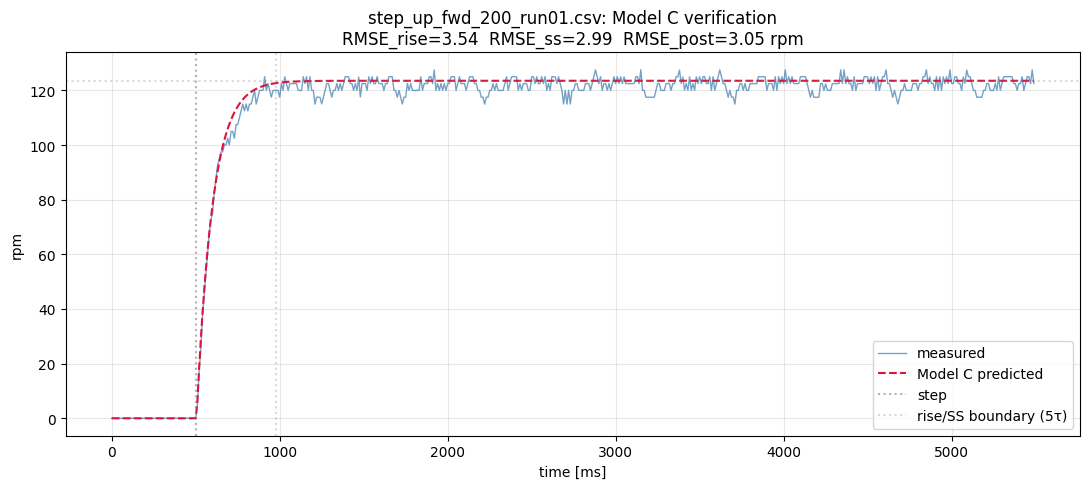

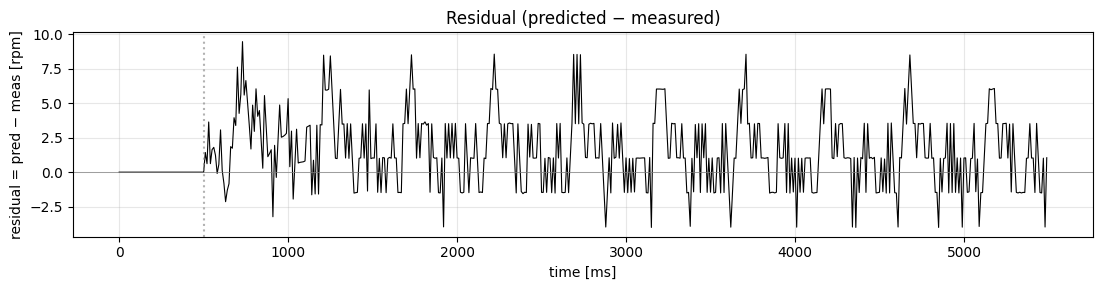

In [5]:
# Cell 4b: signed pwm → simulator → measured-vs-predicted overlay + residuals

# Map dir to signed multiplier
DIR_SIGN = {'F': 1, 'R': -1, 'N': 0}
dir_sign = trial['dir'].map(DIR_SIGN).values
pwm_signed = trial['pwm_cmd'].values * dir_sign

# Sanity-check the signed command
print(f"signed pwm: pre-step (t<500) unique = {sorted(set(pwm_signed[:50]))}")
print(f"signed pwm: post-step unique         = {sorted(set(pwm_signed[50:]))}")

# Run simulator
rpm_meas = trial['rpm'].values
rpm_pred, meta = simulate_model_C(pwm_signed, dt_ms=10, return_meta=True)
print(f"\nSimulator meta: {meta}")

# Windows for RMSE
t = trial['t_ms'].values
t_rise_end = 500 + 5 * meta['tau']
mask_post = t >= 500
mask_rise = (t >= 500) & (t < t_rise_end)
mask_ss   = t >= t_rise_end

rmse_post = np.sqrt(np.mean((rpm_pred[mask_post] - rpm_meas[mask_post])**2))
rmse_rise = np.sqrt(np.mean((rpm_pred[mask_rise] - rpm_meas[mask_rise])**2))
rmse_ss   = np.sqrt(np.mean((rpm_pred[mask_ss]   - rpm_meas[mask_ss])**2))

print(f"\nRMSE post-step (t>=500ms):                  {rmse_post:.3f} rpm")
print(f"RMSE rise      (500<=t<{t_rise_end:.0f}ms ≈ 5τ):       {rmse_rise:.3f} rpm   (per-condition mean rms_rise = 2.48)")
print(f"RMSE steady    (t>={t_rise_end:.0f}ms):                {rmse_ss:.3f} rpm   (per-condition mean rms_ss   = 2.68)")

# Overlay plot
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(t, rpm_meas, color='steelblue', alpha=0.75, linewidth=1.0, label='measured')
ax.plot(t, rpm_pred, color='crimson', linestyle='--', linewidth=1.5, label='Model C predicted')
ax.axvline(500, color='gray', linestyle=':', alpha=0.6, label='step')
ax.axvline(t_rise_end, color='gray', linestyle=':', alpha=0.3, label='rise/SS boundary (5τ)')
ax.axhline(meta['K_ss'], color='gray', linestyle=':', alpha=0.3)
ax.set_xlabel('time [ms]'); ax.set_ylabel('rpm')
ax.set_title(f'{Path(trial_path).name}: Model C verification\n'
             f'RMSE_rise={rmse_rise:.2f}  RMSE_ss={rmse_ss:.2f}  RMSE_post={rmse_post:.2f} rpm')
ax.legend(loc='lower right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# Residual plot
fig2, ax2 = plt.subplots(figsize=(11, 3))
ax2.plot(t, rpm_pred - rpm_meas, color='black', linewidth=0.8)
ax2.axvline(500, color='gray', linestyle=':', alpha=0.6)
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_xlabel('time [ms]'); ax2.set_ylabel('residual = pred − meas [rpm]')
ax2.set_title('Residual (predicted − measured)')
ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [7]:
# Cell 5a-recovery: find any alternative location for held-out data
import os

repo_root = (DATA_RAW / "..").resolve().parent  # notebooks/ → repo root
print(f"Repo root: {repo_root}\n")

# Direct probes of plausible paths
candidates = [
    DATA_RAW / "_sealed",
    DATA_RAW / "sealed",
    DATA_RAW / "_holdout",
    DATA_RAW / "holdout",
    DATA_RAW.parent / "_sealed",
    DATA_RAW.parent / "sealed",
    DATA_RAW.parent / "validation",
    DATA_RAW.parent / "_validation",
    DATA_RAW.parent / "holdout",
    repo_root / "_sealed",
    repo_root / "sealed",
]
print("Direct path probes:")
for p in candidates:
    flag = "EXISTS" if p.exists() else "  --  "
    print(f"  [{flag}] {p}")

# Recursive search for dirs matching 'seal*', 'holdout*', 'valid*'
print("\nRecursive search under repo root:")
SKIP = {'.git', 'node_modules', '__pycache__', '.ipynb_checkpoints', '.venv', 'venv', '.mypy_cache'}
hits = []
for root, dirs, _ in os.walk(repo_root):
    dirs[:] = [d for d in dirs if d not in SKIP]
    for d in dirs:
        if any(k in d.lower() for k in ('seal', 'holdout', 'valid')):
            hits.append(Path(root) / d)
for h in hits:
    n_csv = sum(1 for _ in h.rglob("*.csv")) if h.is_dir() else 0
    print(f"  {h}   ({n_csv} CSVs)")
if not hits:
    print("  (no matches)")

# Also: check .gitignore for hints about what was supposed to exist
gitignore = repo_root / ".gitignore"
if gitignore.exists():
    print(f"\n.gitignore contents:")
    print(gitignore.read_text())

Repo root: /Users/piyush/code/System_Identification_DC_Motor

Direct path probes:
  [  --  ] ../data/raw/_sealed
  [  --  ] ../data/raw/sealed
  [  --  ] ../data/raw/_holdout
  [  --  ] ../data/raw/holdout
  [  --  ] ../data/_sealed
  [  --  ] ../data/sealed
  [  --  ] ../data/validation
  [  --  ] ../data/_validation
  [  --  ] ../data/holdout
  [  --  ] /Users/piyush/code/System_Identification_DC_Motor/_sealed
  [  --  ] /Users/piyush/code/System_Identification_DC_Motor/sealed

Recursive search under repo root:
  (no matches)

.gitignore contents:
# ------------------------------
# macOS / Finder clutter
# ------------------------------
.DS_Store
.DS_Store?
.AppleDouble
.LSOverride
._*
.Spotlight-V100/
.Trashes/
Icon?

# ------------------------------
# VS Code / editor state
# ------------------------------
.vscode/
!.vscode/extensions.json
!.vscode/settings.json
!.vscode/launch.json
!.vscode/tasks.json
!.vscode/*.code-snippets
.history/

# ------------------------------
# PlatformI

In [6]:
# Cell 5a: inventory _sealed/ — LIST ONLY, no reads

sealed_dir = DATA_RAW / "_sealed"
print(f"Inspecting: {sealed_dir.resolve()}")
print(f"Exists: {sealed_dir.exists()}")

if sealed_dir.exists():
    subdirs = sorted([d.name for d in sealed_dir.iterdir() if d.is_dir()])
    files   = sorted([f.name for f in sealed_dir.iterdir() if f.is_file()])

    print(f"\nSubdirectories ({len(subdirs)}):")
    for d in subdirs:
        sub = sealed_dir / d
        n_files = sum(1 for _ in sub.rglob("*") if _.is_file())
        print(f"  {d}/   ({n_files} files inside)")

    print(f"\nLoose files at top level ({len(files)}):")
    for f in files[:20]:
        print(f"  {f}")
    if len(files) > 20:
        print(f"  ... ({len(files)-20} more)")

    # Recursive listing of all CSVs
    all_csvs = sorted([str(p.relative_to(sealed_dir))
                       for p in sealed_dir.rglob("*.csv")])
    print(f"\nAll CSVs (recursive, {len(all_csvs)} total):")
    for c in all_csvs[:30]:
        print(f"  {c}")
    if len(all_csvs) > 30:
        print(f"  ... ({len(all_csvs)-30} more)")
else:
    print("Sealed directory does not exist at expected path. Check repo layout.")

Inspecting: /Users/piyush/code/System_Identification_DC_Motor/data/raw/_sealed
Exists: False
Sealed directory does not exist at expected path. Check repo layout.


In [8]:
# Cell 6a: schema of per-trial fit tables (drives LOOCV loop design)

accel_pt = pd.read_csv(DATA_PROCESSED / "phase21_fopdt_curvefit_per_trial.csv")
decel_pt = pd.read_csv(DATA_PROCESSED / "phase21_stepdown_curvefit_per_trial.csv")

print("=== ACCEL per-trial ===")
print(f"Shape:   {accel_pt.shape}")
print(f"Columns: {list(accel_pt.columns)}")
print("\nFull table:")
print(accel_pt.to_string())

print("\n\n=== DECEL per-trial ===")
print(f"Shape:   {decel_pt.shape}")
print(f"Columns: {list(decel_pt.columns)}")
print("\nFull table:")
print(decel_pt.to_string())

# Quick consistency check
print(f"\n\nTrial counts: accel = {len(accel_pt)} (expect 18), decel = {len(decel_pt)} (expect 12)")

=== ACCEL per-trial ===
Shape:   (18, 10)
Columns: ['direction', 'pwm', 'run', 'K_ss', 'Td_ms', 'tau_ms', 'rms_rise', 'rms_ss', 'rms_total', 'fit_ok']

Full table:
   direction  pwm  run        K_ss         Td_ms      tau_ms  rms_rise    rms_ss  rms_total  fit_ok
0        fwd  160    1   48.957289  2.831386e-15  225.035078  3.166522  1.893446   2.331879    True
1        fwd  160    2   52.997125  1.676108e-11  183.344836  2.101794  2.130269   1.994517    True
2        fwd  160    3   54.275717  3.573347e-14  191.901141  2.576451  2.342288   2.236544    True
3        fwd  200    1  121.986229  4.002627e+00   99.690679  2.565486  2.659660   2.462449    True
4        fwd  200    2  124.405615  5.705928e+00   95.199985  2.364322  2.633509   2.464376    True
5        fwd  200    3  124.184144  5.046736e+00   90.402835  2.502697  2.755374   2.492969    True
6        fwd  240    1  205.086138  1.775890e+01  151.832357  4.536849  4.252959   4.002752    True
7        fwd  240    2  210.789917  

In [9]:
# Cell 6b: simulator with override_params; sanity check vs cell 4b

def simulate_model_C(pwm_cmd, dt_ms=10, return_meta=False, override_params=None):
    """
    Predict RPM trajectory under Model C.

    SCOPE (v1): single-transition step inputs only.

    Parameter source:
      - override_params=None: lookup from accel_params / decel_params tables
      - override_params=dict: use those values directly (for LOOCV / sensitivity)
        Required keys per regime:
          accel: {'K_ss','Td','tau'}
          decel: {'y_init','y_final','Td','tau'}
    """
    pwm_cmd = np.asarray(pwm_cmd, dtype=float)
    n = len(pwm_cmd)

    abs_pwm = np.abs(pwm_cmd)
    diffs = np.diff(abs_pwm)
    transitions = np.where(np.abs(diffs) > 0.5)[0]

    if len(transitions) == 0:
        rpm = np.zeros(n)
        meta = dict(regime="flat", n_transitions=0, used_override=override_params is not None)
        return (rpm, meta) if return_meta else rpm
    if len(transitions) > 1:
        raise NotImplementedError(
            f"v1 supports single-transition trajectories only; "
            f"found {len(transitions)} transitions at samples {transitions.tolist()}.")

    t_step = int(transitions[0] + 1)
    pwm_before = pwm_cmd[t_step - 1]
    pwm_after  = pwm_cmd[t_step]
    abs_before = int(round(abs(pwm_before)))
    abs_after  = int(round(abs(pwm_after)))

    if abs_after > abs_before:
        regime = "accel"
        direction = "fwd" if pwm_after > 0 else "rev"
        if override_params is not None:
            required = {'K_ss', 'Td', 'tau'}
            missing = required - set(override_params.keys())
            assert not missing, f"accel override missing keys: {missing}"
            p = {k: float(override_params[k]) for k in required}
        else:
            p = get_accel_params(direction, abs_after)
        y_init, y_final = 0.0, p['K_ss']
    else:
        regime = "decel"
        direction = "fwd" if pwm_before > 0 else "rev"
        if override_params is not None:
            required = {'y_init', 'y_final', 'Td', 'tau'}
            missing = required - set(override_params.keys())
            assert not missing, f"decel override missing keys: {missing}"
            p = {k: float(override_params[k]) for k in required}
        else:
            p = get_decel_params(direction, abs_before, abs_after)
        y_init, y_final = p['y_init'], p['y_final']

    Td, tau = p['Td'], p['tau']

    rpm = np.empty(n)
    rpm[:t_step] = 0.0 if regime == "accel" else y_init
    for k in range(t_step, n):
        elapsed_ms = (k - t_step) * dt_ms - Td
        if elapsed_ms < 0:
            rpm[k] = y_init if regime == "decel" else 0.0
        else:
            rpm[k] = y_final + (y_init - y_final) * np.exp(-elapsed_ms / tau)

    meta = dict(regime=regime, direction=direction,
                pwm_before=abs_before, pwm_after=abs_after,
                K_ss=y_final, y_init=y_init, Td=Td, tau=tau, t_step=t_step,
                used_override=override_params is not None)
    return (rpm, meta) if return_meta else rpm


# --- Sanity: override path with per-condition mean must match lookup path exactly ---
row = accel_params.query("direction=='fwd' and pwm==200").iloc[0]
override = {'K_ss': float(row.K_ss_mean), 'Td': float(row.Td_mean), 'tau': float(row.tau_mean)}
print(f"Override (per-condition mean, fwd PWM=200): {override}")

rpm_override, meta_override = simulate_model_C(pwm_signed, return_meta=True,
                                                override_params=override)
rpm_lookup,   meta_lookup   = simulate_model_C(pwm_signed, return_meta=True)

diff_max = np.max(np.abs(rpm_override - rpm_lookup))
print(f"\nMax |rpm_override - rpm_lookup|: {diff_max:.3e}  (expect 0 or ~1e-15)")
print(f"meta_override.used_override = {meta_override['used_override']}  (expect True)")
print(f"meta_lookup.used_override   = {meta_lookup['used_override']}   (expect False)")

assert diff_max < 1e-9, "Override path diverges from lookup path — bug!"
print("\n✓ Override path verified: bit-for-bit identical to lookup path when given same params.")

Override (per-condition mean, fwd PWM=200): {'K_ss': 123.525329650448, 'Td': 4.9184304303828315, 'tau': 95.0978334503218}

Max |rpm_override - rpm_lookup|: 0.000e+00  (expect 0 or ~1e-15)
meta_override.used_override = True  (expect True)
meta_lookup.used_override   = False   (expect False)

✓ Override path verified: bit-for-bit identical to lookup path when given same params.


In [10]:
# Cell 6c: LOOCV — accel (18 step-up trials)

DIR_SIGN = {'F': 1, 'R': -1, 'N': 0}
STEP_START_MS = 500

def load_trial(kind, direction, pwm_or_pair, run):
    """Load a step trial CSV by metadata."""
    if kind == 'up':
        fname = f"step_up_{direction}_{pwm_or_pair}_run{run:02d}.csv"
    else:
        start, target = pwm_or_pair
        fname = f"step_down_{direction}_{start}to{target}_run{run:02d}.csv"
    return pd.read_csv(DATA_RAW / "step_responses" / fname)

def signed_pwm(trial_df):
    return trial_df['pwm_cmd'].values * trial_df['dir'].map(DIR_SIGN).values

def _rmse(a, b, mask):
    return float(np.sqrt(np.mean((a[mask] - b[mask])**2)))

# --- LOOCV loop ---
accel_results = []
for _, row in accel_pt.iterrows():
    direction, pwm, run = row['direction'], int(row['pwm']), int(row['run'])
    others = accel_pt[(accel_pt.direction == direction) &
                      (accel_pt.pwm == pwm) &
                      (accel_pt.run != run)]
    assert len(others) == 2, \
        f"Expected 2 others at {direction} pwm={pwm} run={run}, got {len(others)}"

    override = {
        'K_ss': float(others.K_ss.mean()),
        'Td':   float(others.Td_ms.mean()),
        'tau':  float(others.tau_ms.mean()),
    }
    trial = load_trial('up', direction, pwm, run)
    pwm_sig  = signed_pwm(trial)
    rpm_meas = trial['rpm'].values
    rpm_pred, meta = simulate_model_C(pwm_sig, dt_ms=10, return_meta=True,
                                      override_params=override)

    t = trial['t_ms'].values
    t_rise_end = STEP_START_MS + 5 * meta['tau']
    mask_post = t >= STEP_START_MS
    mask_rise = (t >= STEP_START_MS) & (t < t_rise_end)
    mask_ss   = t >= t_rise_end

    accel_results.append({
        'direction': direction, 'pwm': pwm, 'run': run,
        'K_ss_loocv': override['K_ss'], 'Td_loocv': override['Td'], 'tau_loocv': override['tau'],
        'K_ss_self':  float(row.K_ss), 'Td_self':  float(row.Td_ms), 'tau_self':  float(row.tau_ms),
        'rmse_post':  _rmse(rpm_pred, rpm_meas, mask_post),
        'rmse_rise':  _rmse(rpm_pred, rpm_meas, mask_rise),
        'rmse_ss':    _rmse(rpm_pred, rpm_meas, mask_ss),
        'rms_rise_self_floor': float(row.rms_rise),
        'rms_ss_self_floor':   float(row.rms_ss),
    })

accel_loocv = pd.DataFrame(accel_results)

# Per-condition aggregate
agg = (accel_loocv.groupby(['direction','pwm'])
       .agg(rmse_rise_mean=('rmse_rise','mean'), rmse_rise_std=('rmse_rise','std'),
            rmse_ss_mean  =('rmse_ss','mean'),   rmse_ss_std  =('rmse_ss','std'),
            rms_rise_floor=('rms_rise_self_floor','mean'),
            rms_ss_floor  =('rms_ss_self_floor','mean'))
       .reset_index())

print("=== ACCEL LOOCV per-trial (18 trials) ===")
print(accel_loocv.round(3).to_string())
print("\n=== ACCEL LOOCV per-condition summary ===")
print(agg.round(3).to_string())

# Save
out_path = DATA_PROCESSED / "phase21_loocv_accel.csv"
accel_loocv.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

# Soft sanity: LOOCV RMSE_rise should NOT beat per-trial fit residual by much
# (curve_fit minimizes residuals on its own params; LOOCV uses different params)
beats_floor = accel_loocv[accel_loocv.rmse_rise + 0.5 < accel_loocv.rms_rise_self_floor]
if len(beats_floor) > 0:
    print(f"\n⚠ {len(beats_floor)} trial(s) where LOOCV RMSE_rise beats per-trial fit residual "
          f"by >0.5 rpm — investigate (window definition mismatch likely):")
    print(beats_floor[['direction','pwm','run','rmse_rise','rms_rise_self_floor']].to_string())
else:
    print("\n✓ All 18 LOOCV RMSE_rise values consistent with per-trial fit residuals.")

=== ACCEL LOOCV per-trial (18 trials) ===
   direction  pwm  run  K_ss_loocv  Td_loocv  tau_loocv  K_ss_self  Td_self  tau_self  rmse_post  rmse_rise  rmse_ss  rms_rise_self_floor  rms_ss_self_floor
0        fwd  160    1      53.636     0.000    187.623     48.957    0.000   225.035      5.470      7.382    4.922                3.167              1.893
1        fwd  160    2      51.617     0.000    208.468     52.997    0.000   183.345      2.667      3.045    2.557                2.102              2.130
2        fwd  160    3      50.977     0.000    204.190     54.276    0.000   191.901      4.056      3.341    4.222                2.576              2.342
3        fwd  200    1     124.295     5.376     92.801    121.986    4.003    99.691      3.548      4.413    3.445                2.565              2.660
4        fwd  200    2     123.085     4.525     95.047    124.406    5.706    95.200      2.889      1.965    2.971                2.364              2.634
5        fwd  20

In [11]:
# Cell 6d: LOOCV — decel (12 step-down trials)

STEP_DOWN_START_MS = 3000

decel_results = []
for _, row in decel_pt.iterrows():
    direction  = row['direction']
    start_pwm  = int(row['start_pwm'])
    target_pwm = int(row['target_pwm'])
    run        = int(row['run'])

    others = decel_pt[(decel_pt.direction == direction) &
                      (decel_pt.start_pwm == start_pwm) &
                      (decel_pt.target_pwm == target_pwm) &
                      (decel_pt.run != run)]
    assert len(others) == 2, \
        f"Expected 2 others at {direction} {start_pwm}->{target_pwm} run={run}, got {len(others)}"

    override = {
        'y_init':  float(others.y_init.mean()),
        'y_final': float(others.y_final.mean()),
        'Td':      float(others.Td_ms.mean()),
        'tau':     float(others.tau_ms.mean()),
    }
    trial = load_trial('down', direction, (start_pwm, target_pwm), run)
    pwm_sig  = signed_pwm(trial)
    rpm_meas = trial['rpm'].values
    rpm_pred, meta = simulate_model_C(pwm_sig, dt_ms=10, return_meta=True,
                                      override_params=override)

    t = trial['t_ms'].values
    mask_post = t >= STEP_DOWN_START_MS

    decel_results.append({
        'direction': direction, 'start_pwm': start_pwm, 'target_pwm': target_pwm, 'run': run,
        'y_init_loocv':  override['y_init'],  'y_final_loocv': override['y_final'],
        'Td_loocv':      override['Td'],      'tau_loocv':     override['tau'],
        'y_init_self':   float(row.y_init),   'y_final_self':  float(row.y_final),
        'Td_self':       float(row.Td_ms),    'tau_self':      float(row.tau_ms),
        'rmse_post':     _rmse(rpm_pred, rpm_meas, mask_post),
        'rms_decel_self_floor': float(row.rms_decel),
    })

decel_loocv = pd.DataFrame(decel_results)

agg_decel = (decel_loocv.groupby(['direction','start_pwm','target_pwm'])
             .agg(rmse_post_mean=('rmse_post','mean'),
                  rmse_post_std =('rmse_post','std'),
                  rms_decel_floor=('rms_decel_self_floor','mean'))
             .reset_index())

print("=== DECEL LOOCV per-trial (12 trials) ===")
print(decel_loocv.round(3).to_string())
print("\n=== DECEL LOOCV per-condition summary ===")
print(agg_decel.round(3).to_string())

out_path = DATA_PROCESSED / "phase21_loocv_decel.csv"
decel_loocv.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

# Soft sanity
beats_floor = decel_loocv[decel_loocv.rmse_post + 0.5 < decel_loocv.rms_decel_self_floor]
if len(beats_floor) > 0:
    print(f"\n⚠ {len(beats_floor)} trial(s) where LOOCV RMSE beats per-trial fit residual by >0.5 rpm:")
    print(beats_floor[['direction','start_pwm','target_pwm','run',
                       'rmse_post','rms_decel_self_floor']].to_string())
else:
    print("\n✓ All 12 LOOCV RMSE values consistent with per-trial fit residuals.")

=== DECEL LOOCV per-trial (12 trials) ===
   direction  start_pwm  target_pwm  run  y_init_loocv  y_final_loocv  Td_loocv  tau_loocv  y_init_self  y_final_self  Td_self  tau_self  rmse_post  rms_decel_self_floor
0        fwd        240           0    1       214.233         -0.709    54.446    173.027      214.340        -0.665   56.677   170.508      4.722                 8.532
1        fwd        240           0    2       214.434         -0.682    56.326    171.259      213.938        -0.719   52.917   174.042      4.880                 8.768
2        fwd        240           0    3       214.139         -0.692    54.797    172.275      214.528        -0.699   55.975   172.011      4.820                 8.715
3        fwd        240         160    1       215.850         73.122    11.915    279.921      215.392        75.020   18.355   265.920      3.992                 4.310
4        fwd        240         160    2       215.666         73.952    13.351    274.619      215.760     

In [12]:
# Cell 6d-followup: identify the window definition behind `rms_decel`

trial = load_trial('down', 'fwd', (240, 0), 1)
pwm_sig  = signed_pwm(trial)
rpm_meas = trial['rpm'].values
t = trial['t_ms'].values

# Use this trial's OWN per-trial params (clean reference, no LOOCV substitution)
self_row = decel_pt[(decel_pt.direction == 'fwd') &
                    (decel_pt.start_pwm == 240) &
                    (decel_pt.target_pwm == 0) &
                    (decel_pt.run == 1)].iloc[0]
override_self = {
    'y_init':  float(self_row.y_init),
    'y_final': float(self_row.y_final),
    'Td':      float(self_row.Td_ms),
    'tau':     float(self_row.tau_ms),
}
rpm_pred_self = simulate_model_C(pwm_sig, override_params=override_self)

print(f"Trial: step_down_fwd_240to0_run01")
print(f"Targets to match: rms_decel = {self_row.rms_decel:.3f},  rms_total = {self_row.rms_total:.3f}")
print(f"Self params: y_init={override_self['y_init']:.2f}, y_final={override_self['y_final']:.3f}, "
      f"Td={override_self['Td']:.2f} ms, tau={override_self['tau']:.2f} ms")

tau = override_self['tau']
windows = [
    ("full trial             [0, end]",                  np.ones_like(t, dtype=bool)),
    ("fit window             [2000, end]",               t >= 2000),
    ("pre-step only          [2000, 3000)",              (t >= 2000) & (t < 3000)),
    ("post-step              [3000, end]",               t >= 3000),
    ("transient 5τ           [3000, 3000+5τ]",           (t >= 3000) & (t < 3000 + 5*tau)),
    ("transient 3τ           [3000, 3000+3τ]",           (t >= 3000) & (t < 3000 + 3*tau)),
    ("transient 4τ           [3000, 3000+4τ]",           (t >= 3000) & (t < 3000 + 4*tau)),
    ("transient (Td+5τ)      [3000+Td, 3000+Td+5τ]",     (t >= 3000+override_self['Td']) & (t < 3000+override_self['Td']+5*tau)),
    ("post-transient SS      [3000+5τ, end]",            t >= 3000 + 5*tau),
]

print(f"\nResiduals on candidate windows (using SELF params):")
print(f"  {'window':<40s} {'n':>5s} {'RMSE':>8s}")
for name, mask in windows:
    n = int(mask.sum())
    if n > 0:
        r = float(np.sqrt(np.mean((rpm_pred_self[mask] - rpm_meas[mask])**2)))
        match = ""
        if abs(r - self_row.rms_decel) < 0.1:
            match = "  ← matches rms_decel ✓"
        elif abs(r - self_row.rms_total) < 0.1:
            match = "  ← matches rms_total ✓"
        print(f"  {name:<40s} {n:>5d} {r:>8.3f}{match}")

Trial: step_down_fwd_240to0_run01
Targets to match: rms_decel = 8.532,  rms_total = 5.153
Self params: y_init=214.34, y_final=-0.665, Td=56.68 ms, tau=170.51 ms

Residuals on candidate windows (using SELF params):
  window                                       n     RMSE
  full trial             [0, end]            801   24.300
  fit window             [2000, end]         601    5.153  ← matches rms_total ✓
  pre-step only          [2000, 3000)        100    6.940
  post-step              [3000, end]         501    4.717
  transient 5τ           [3000, 3000+5τ]      86   11.296
  transient 3τ           [3000, 3000+3τ]      52   13.485
  transient 4τ           [3000, 3000+4τ]      69   12.528
  transient (Td+5τ)      [3000+Td, 3000+Td+5τ]    85    9.839
  post-transient SS      [3000+5τ, end]      415    0.644


In [13]:
# Cell 6d-revised: decel LOOCV with corrected floor comparison

decel_results = []
for _, row in decel_pt.iterrows():
    direction  = row['direction']
    start_pwm  = int(row['start_pwm'])
    target_pwm = int(row['target_pwm'])
    run        = int(row['run'])

    others = decel_pt[(decel_pt.direction == direction) &
                      (decel_pt.start_pwm == start_pwm) &
                      (decel_pt.target_pwm == target_pwm) &
                      (decel_pt.run != run)]
    assert len(others) == 2

    override = {
        'y_init':  float(others.y_init.mean()),
        'y_final': float(others.y_final.mean()),
        'Td':      float(others.Td_ms.mean()),
        'tau':     float(others.tau_ms.mean()),
    }
    trial = load_trial('down', direction, (start_pwm, target_pwm), run)
    pwm_sig  = signed_pwm(trial)
    rpm_meas = trial['rpm'].values
    rpm_pred, meta = simulate_model_C(pwm_sig, dt_ms=10, return_meta=True,
                                      override_params=override)

    t = trial['t_ms'].values
    mask_fit  = t >= 2000              # matches curve_fit's fit window → compare to rms_total
    mask_post = t >= STEP_DOWN_START_MS # post-step only (transient + SS)
    mask_transient = (t >= STEP_DOWN_START_MS) & (t < STEP_DOWN_START_MS + 5*meta['tau'])
    mask_ss   = t >= STEP_DOWN_START_MS + 5*meta['tau']

    decel_results.append({
        'direction': direction, 'start_pwm': start_pwm, 'target_pwm': target_pwm, 'run': run,
        'y_init_loocv':  override['y_init'],  'y_final_loocv': override['y_final'],
        'Td_loocv':      override['Td'],      'tau_loocv':     override['tau'],
        'y_init_self':   float(row.y_init),   'y_final_self':  float(row.y_final),
        'Td_self':       float(row.Td_ms),    'tau_self':      float(row.tau_ms),
        'rmse_fit_window': _rmse(rpm_pred, rpm_meas, mask_fit),
        'rmse_post':       _rmse(rpm_pred, rpm_meas, mask_post),
        'rmse_transient':  _rmse(rpm_pred, rpm_meas, mask_transient),
        'rmse_ss':         _rmse(rpm_pred, rpm_meas, mask_ss),
        'rms_total_self_floor': float(row.rms_total),
        'rms_decel_self_diag':  float(row.rms_decel),  # diagnostic, not floor
    })

decel_loocv = pd.DataFrame(decel_results)

agg_decel = (decel_loocv.groupby(['direction','start_pwm','target_pwm'])
             .agg(rmse_fit_mean=('rmse_fit_window','mean'),
                  rmse_fit_std =('rmse_fit_window','std'),
                  rmse_post_mean=('rmse_post','mean'),
                  rmse_transient_mean=('rmse_transient','mean'),
                  rmse_ss_mean=('rmse_ss','mean'),
                  rms_total_floor=('rms_total_self_floor','mean'))
             .reset_index())

print("=== DECEL LOOCV per-trial (12 trials) ===")
print(decel_loocv.round(3).to_string())
print("\n=== DECEL LOOCV per-condition summary ===")
print(agg_decel.round(3).to_string())

# Save (overwrites the previous decel CSV with corrected schema)
out_path = DATA_PROCESSED / "phase21_loocv_decel.csv"
decel_loocv.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

# Apples-to-apples sanity check: LOOCV rmse_fit_window vs per-trial rms_total
beats_floor = decel_loocv[decel_loocv.rmse_fit_window + 0.5 < decel_loocv.rms_total_self_floor]
if len(beats_floor) > 0:
    print(f"\n⚠ {len(beats_floor)} trial(s) where LOOCV rmse_fit_window beats rms_total floor by >0.5 rpm:")
    print(beats_floor[['direction','start_pwm','target_pwm','run',
                       'rmse_fit_window','rms_total_self_floor']].to_string())
else:
    print("\n✓ All 12 LOOCV rmse_fit_window values consistent with rms_total floors.")

=== DECEL LOOCV per-trial (12 trials) ===
   direction  start_pwm  target_pwm  run  y_init_loocv  y_final_loocv  Td_loocv  tau_loocv  y_init_self  y_final_self  Td_self  tau_self  rmse_fit_window  rmse_post  rmse_transient  rmse_ss  rms_total_self_floor  rms_decel_self_diag
0        fwd        240           0    1       214.233         -0.709    54.446    173.027      214.340        -0.665   56.677   170.508            5.160      4.722          11.234    0.684                 5.153                8.532
1        fwd        240           0    2       214.434         -0.682    56.326    171.259      213.938        -0.719   52.917   174.042            5.242      4.880          11.690    0.660                 5.221                8.768
2        fwd        240           0    3       214.139         -0.692    54.797    172.275      214.528        -0.699   55.975   172.011            5.111      4.820          11.464    0.667                 5.105                8.715
3        fwd        240   

=== Phase 2.2 LOOCV summary (10 conditions, 30 trials) ===
    type direction condition  n_trials  loocv_rmse_mean  loocv_rmse_std  in_sample_floor  excess
0  accel       fwd   PWM=160         3            4.589           2.423            2.615   1.974
1  accel       fwd   PWM=200         3            3.299           1.239            2.478   0.822
2  accel       fwd   PWM=240         3            6.440           0.518            4.689   1.751
3  accel       rev   PWM=160         3            5.161           0.356            4.029   1.132
4  accel       rev   PWM=200         3            2.363           0.090            2.658  -0.295
5  accel       rev   PWM=240         3            8.125           0.863            7.173   0.952
6  decel       fwd     240→0         3            5.171           0.066            5.160   0.012
7  decel       fwd   240→160         3            4.463           0.062            4.316   0.147
8  decel       rev     240→0         3            5.412           0.

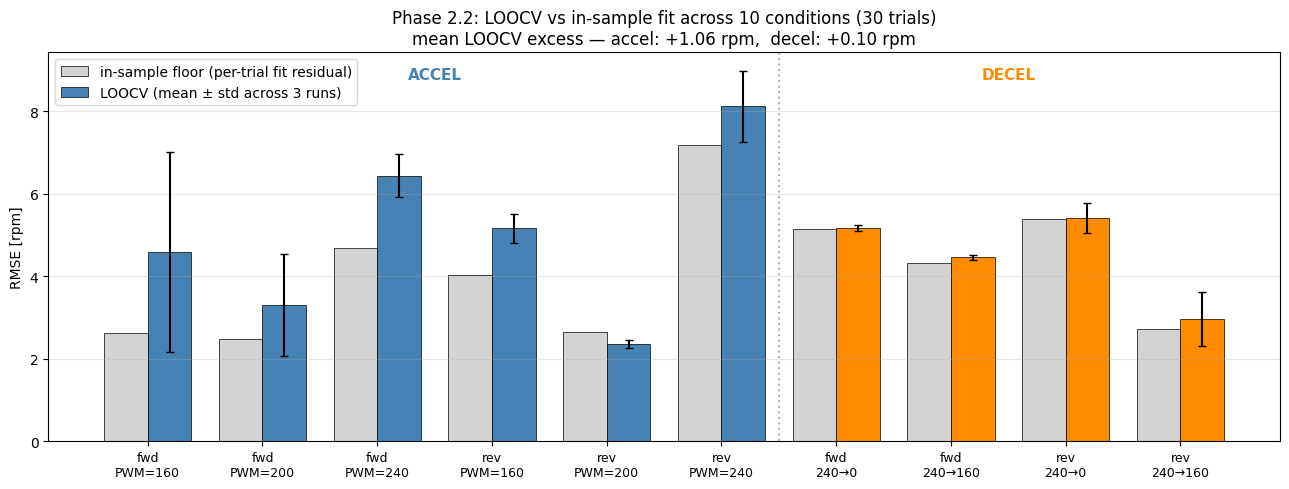


Saved figure: ../figures/12_phase22_loocv_summary.png


In [14]:
# Cell 6e: unified Phase 2.2 LOOCV summary + figure

# --- Build unified summary ---
# Accel: primary metric = rmse_rise vs in-sample rms_rise floor (rise-window apples-to-apples)
accel_summary = (accel_loocv.groupby(['direction','pwm'])
                 .agg(n_trials=('rmse_rise','count'),
                      loocv_rmse_mean=('rmse_rise','mean'),
                      loocv_rmse_std=('rmse_rise','std'),
                      in_sample_floor=('rms_rise_self_floor','mean'))
                 .reset_index())
accel_summary['type']      = 'accel'
accel_summary['condition'] = accel_summary['pwm'].apply(lambda p: f"PWM={p}")
accel_summary['excess']    = accel_summary['loocv_rmse_mean'] - accel_summary['in_sample_floor']

# Decel: primary metric = rmse_fit_window vs rms_total floor (fit-window apples-to-apples)
decel_summary = (decel_loocv.groupby(['direction','start_pwm','target_pwm'])
                 .agg(n_trials=('rmse_fit_window','count'),
                      loocv_rmse_mean=('rmse_fit_window','mean'),
                      loocv_rmse_std=('rmse_fit_window','std'),
                      in_sample_floor=('rms_total_self_floor','mean'))
                 .reset_index())
decel_summary['type']      = 'decel'
decel_summary['condition'] = decel_summary.apply(
    lambda r: f"{int(r['start_pwm'])}→{int(r['target_pwm'])}", axis=1)
decel_summary['excess']    = decel_summary['loocv_rmse_mean'] - decel_summary['in_sample_floor']

cols = ['type','direction','condition','n_trials',
        'loocv_rmse_mean','loocv_rmse_std','in_sample_floor','excess']
combined = pd.concat([accel_summary[cols], decel_summary[cols]], ignore_index=True)

print("=== Phase 2.2 LOOCV summary (10 conditions, 30 trials) ===")
print(combined.round(3).to_string())

# Save
out_path = DATA_PROCESSED / "phase21_loocv_summary.csv"
combined.to_csv(out_path, index=False)
print(f"\nSaved: {out_path}")

# Headline numbers
print(f"\nHeadline:")
print(f"  Accel mean LOOCV excess: {accel_summary.excess.mean():+.2f} rpm  "
      f"(std {accel_summary.excess.std():.2f}, n={len(accel_summary)} conditions)")
print(f"  Decel mean LOOCV excess: {decel_summary.excess.mean():+.2f} rpm  "
      f"(std {decel_summary.excess.std():.2f}, n={len(decel_summary)} conditions)")
worst = combined.loc[combined.excess.idxmax()]
print(f"  Worst condition: {worst['type']} {worst['direction']} {worst['condition']}  "
      f"excess={worst['excess']:+.2f} rpm")

# --- Bar chart: LOOCV vs floor per condition ---
FIGURES = Path("../figures")
FIGURES.mkdir(exist_ok=True)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(combined))
width = 0.38

ax.bar(x - width/2, combined['in_sample_floor'], width,
       label='in-sample floor (per-trial fit residual)',
       color='lightgray', edgecolor='black', linewidth=0.5)

bar_colors = ['steelblue' if t == 'accel' else 'darkorange' for t in combined['type']]
ax.bar(x + width/2, combined['loocv_rmse_mean'], width,
       yerr=combined['loocv_rmse_std'].fillna(0), capsize=3,
       label='LOOCV (mean ± std across 3 runs)',
       color=bar_colors, edgecolor='black', linewidth=0.5)

labels = [f"{r['direction']}\n{r['condition']}" for _, r in combined.iterrows()]
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('RMSE [rpm]')
ax.set_title(f'Phase 2.2: LOOCV vs in-sample fit across 10 conditions (30 trials)\n'
             f'mean LOOCV excess — accel: {accel_summary.excess.mean():+.2f} rpm,  '
             f'decel: {decel_summary.excess.mean():+.2f} rpm')

# Accel/decel divider
ax.axvline(len(accel_summary) - 0.5, color='gray', linestyle=':', alpha=0.6)
ymax = ax.get_ylim()[1]
ax.text((len(accel_summary)-1)/2, ymax*0.93, 'ACCEL', ha='center', fontsize=11,
        color='steelblue', fontweight='bold')
ax.text(len(accel_summary) + (len(decel_summary)-1)/2, ymax*0.93, 'DECEL', ha='center',
        fontsize=11, color='darkorange', fontweight='bold')

ax.legend(loc='upper left')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()

fig_path = FIGURES / "12_phase22_loocv_summary.png"
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"\nSaved figure: {fig_path}")

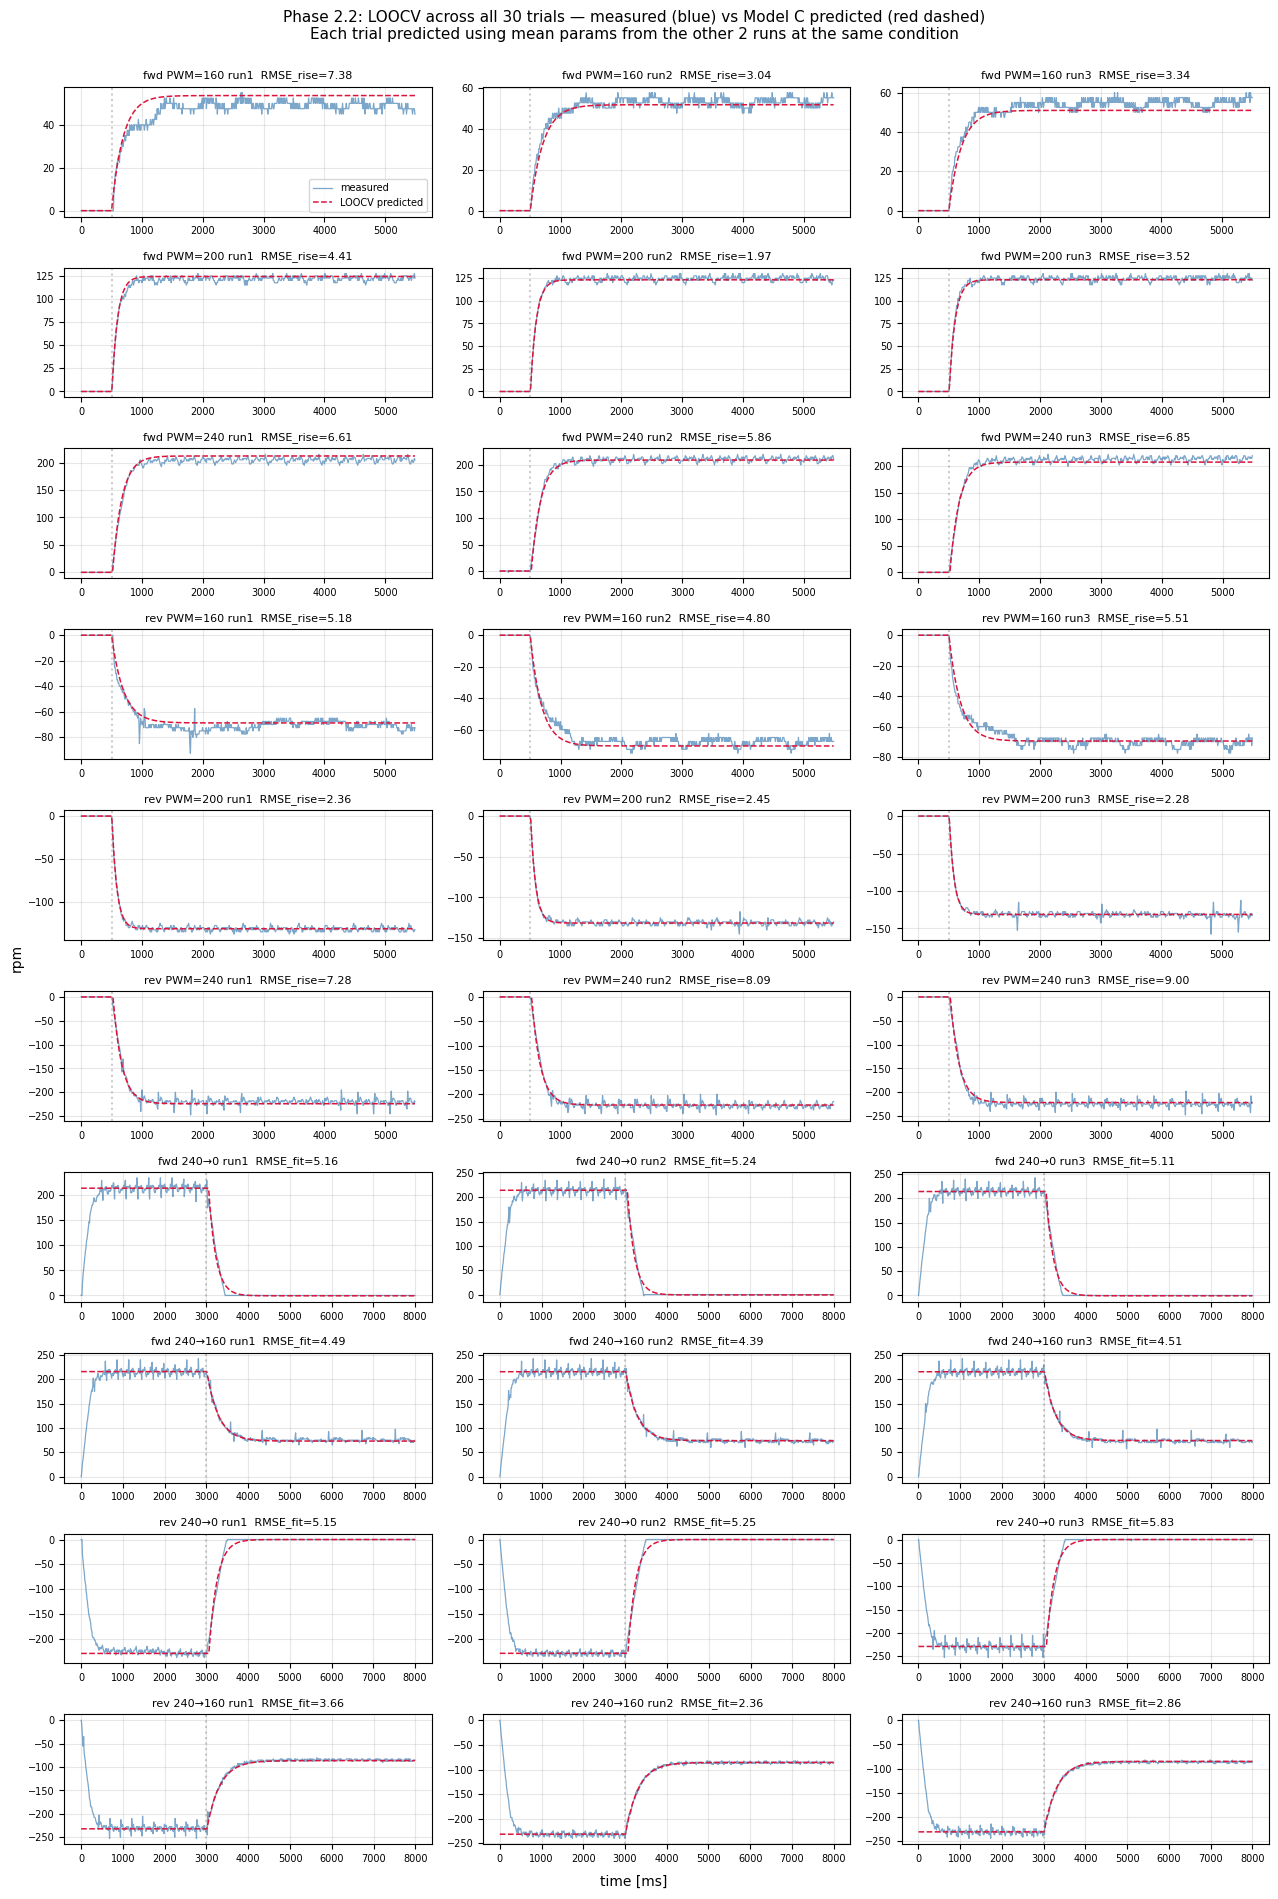

Saved: ../figures/13_phase22_loocv_grid.png
30 panels rendered.


In [15]:
# Cell 6f: 30-trial overlay grid for thesis appendix

def _plot_panel(ax, t, rpm_meas, rpm_pred, step_ms, title):
    ax.plot(t, rpm_meas, color='steelblue', alpha=0.7, linewidth=0.9, label='measured')
    ax.plot(t, rpm_pred, color='crimson', linestyle='--', linewidth=1.1, label='LOOCV predicted')
    ax.axvline(step_ms, color='gray', linestyle=':', alpha=0.4)
    ax.set_title(title, fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(True, alpha=0.3)

accel_conditions = [('fwd', 160), ('fwd', 200), ('fwd', 240),
                    ('rev', 160), ('rev', 200), ('rev', 240)]
decel_conditions = [('fwd', 240, 0), ('fwd', 240, 160),
                    ('rev', 240, 0), ('rev', 240, 160)]

n_rows = len(accel_conditions) + len(decel_conditions)  # 10
fig, axes = plt.subplots(n_rows, 3, figsize=(13, 1.9*n_rows))

# --- Accel panels (rows 0-5) ---
for row_idx, (direction, pwm) in enumerate(accel_conditions):
    for run in (1, 2, 3):
        ax = axes[row_idx, run-1]

        others = accel_pt[(accel_pt.direction == direction) &
                          (accel_pt.pwm == pwm) & (accel_pt.run != run)]
        override = {'K_ss': float(others.K_ss.mean()),
                    'Td':   float(others.Td_ms.mean()),
                    'tau':  float(others.tau_ms.mean())}

        trial = load_trial('up', direction, pwm, run)
        pwm_sig = signed_pwm(trial)
        rpm_pred = simulate_model_C(pwm_sig, override_params=override)

        rec = accel_loocv[(accel_loocv.direction == direction) &
                          (accel_loocv.pwm == pwm) &
                          (accel_loocv.run == run)].iloc[0]

        _plot_panel(ax, trial['t_ms'].values, trial['rpm'].values, rpm_pred,
                    STEP_START_MS,
                    f"{direction} PWM={pwm} run{run}  RMSE_rise={rec.rmse_rise:.2f}")

# --- Decel panels (rows 6-9) ---
for sub_idx, (direction, start_pwm, target_pwm) in enumerate(decel_conditions):
    row_idx = len(accel_conditions) + sub_idx
    for run in (1, 2, 3):
        ax = axes[row_idx, run-1]

        others = decel_pt[(decel_pt.direction == direction) &
                          (decel_pt.start_pwm == start_pwm) &
                          (decel_pt.target_pwm == target_pwm) &
                          (decel_pt.run != run)]
        override = {'y_init':  float(others.y_init.mean()),
                    'y_final': float(others.y_final.mean()),
                    'Td':      float(others.Td_ms.mean()),
                    'tau':     float(others.tau_ms.mean())}

        trial = load_trial('down', direction, (start_pwm, target_pwm), run)
        pwm_sig = signed_pwm(trial)
        rpm_pred = simulate_model_C(pwm_sig, override_params=override)

        rec = decel_loocv[(decel_loocv.direction == direction) &
                          (decel_loocv.start_pwm == start_pwm) &
                          (decel_loocv.target_pwm == target_pwm) &
                          (decel_loocv.run == run)].iloc[0]

        _plot_panel(ax, trial['t_ms'].values, trial['rpm'].values, rpm_pred,
                    STEP_DOWN_START_MS,
                    f"{direction} {start_pwm}→{target_pwm} run{run}  RMSE_fit={rec.rmse_fit_window:.2f}")

# One legend on first panel
axes[0, 0].legend(loc='lower right', fontsize=7)

# Shared labels
fig.suptitle('Phase 2.2: LOOCV across all 30 trials — measured (blue) vs Model C predicted (red dashed)\n'
             'Each trial predicted using mean params from the other 2 runs at the same condition',
             fontsize=11, y=0.999)
fig.supxlabel('time [ms]', fontsize=10)
fig.supylabel('rpm', fontsize=10)

plt.tight_layout()
fig_path = FIGURES / "13_phase22_loocv_grid.png"
plt.savefig(fig_path, dpi=140, bbox_inches='tight')
plt.show()
print(f"Saved: {fig_path}")
print(f"30 panels rendered.")